# Fusion Experiments

## Objective
This notebook compares unimodal and synthetic multimodal models under repeated seeds. It includes both same-label pairing and random-pairing controls so that apparent gains can be interpreted critically rather than at face value.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs_v2'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from src.fusion import (
    load_frozen_wisconsin_dataframe,
    run_late_fusion_experiment,
    run_logistic_fusion_experiment,
    summarise_experiment_rows,
)
from src.pairing import build_random_pairs, build_same_label_pairs

wisconsin = load_frozen_wisconsin_dataframe(WISCONSIN_ROOT / 'brca.csv')
image_embeddings = pd.read_csv(REPORTS / 'breakhis_patient_level_embeddings.csv')
seeds = [11, 21, 31, 41, 51]
rows = []


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs_v2


In [2]:
for pairing_name, builder in [('same_label', build_same_label_pairs), ('random', build_random_pairs)]:
    for seed in seeds:
        paired = builder(wisconsin, image_embeddings, random_state=seed).paired
        experiments = {
            'tabular_only': run_logistic_fusion_experiment(paired, random_state=seed, feature_prefixes=('tab_',)),
            'image_only': run_logistic_fusion_experiment(paired, random_state=seed, feature_prefixes=('img_img_emb_',)),
            'early_fusion': run_logistic_fusion_experiment(paired, random_state=seed),
            'late_fusion': run_late_fusion_experiment(paired, random_state=seed),
        }
        for experiment_name, result in experiments.items():
            for metric_name, metric_value in result.metrics.items():
                rows.append(
                    {
                        'pairing_type': pairing_name,
                        'seed': seed,
                        'experiment': experiment_name,
                        'metric': metric_name,
                        'value': metric_value,
                    }
                )
results_df = pd.DataFrame(rows)
results_df.to_csv(METRICS / 'synthetic_fusion_experiments.csv', index=False)
summary_df = summarise_experiment_rows(results_df)
summary_df.to_csv(METRICS / 'synthetic_fusion_summary.csv', index=False)
summary_df.head(20)


,pairing_type,experiment,metric,mean,std,min,max
0,random,early_fusion,accuracy,0.971930,0.020003,0.938596,0.991228
1,random,early_fusion,brier_score,0.023558,0.013549,0.009933,0.043916
2,random,early_fusion,f1_score,0.961503,0.027512,0.915663,0.987952
3,random,early_fusion,precision,0.970848,0.026746,0.926829,1.000000
4,random,early_fusion,recall,0.952381,0.029161,0.904762,0.976190
5,random,early_fusion,roc_auc,0.991799,0.010191,0.976852,0.999339
6,random,image_only,accuracy,0.582456,0.045833,0.508772,0.622807
7,random,image_only,brier_score,0.282536,0.027133,0.260963,0.326793
8,random,image_only,f1_score,0.341367,0.079527,0.222222,0.441558
9,random,image_only,precision,0.406467,0.086647,0.266667,0.485714


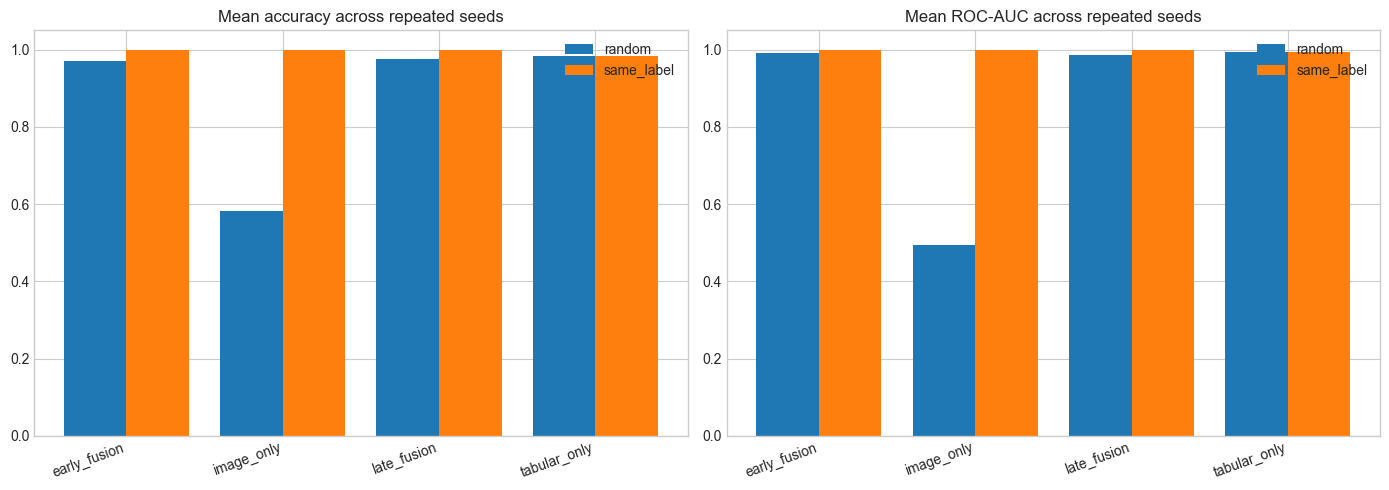

In [3]:
accuracy_plot_df = summary_df[summary_df['metric'] == 'accuracy']
roc_plot_df = summary_df[summary_df['metric'] == 'roc_auc']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric_df, title in [
    (axes[0], accuracy_plot_df, 'Mean accuracy across repeated seeds'),
    (axes[1], roc_plot_df, 'Mean ROC-AUC across repeated seeds'),
]:
    pairings = metric_df['pairing_type'].unique()
    experiments = metric_df['experiment'].unique()
    width = 0.8 / len(pairings)
    x = np.arange(len(experiments))
    for idx, pairing in enumerate(pairings):
        subset = metric_df[metric_df['pairing_type'] == pairing].set_index('experiment').reindex(experiments)
        ax.bar(x + (idx - (len(pairings)-1)/2)*width, subset['mean'], width=width, label=pairing)
    ax.set_xticks(x, experiments)
    ax.set_title(title)
    ax.legend()
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
fig.savefig(FIGURES / 'fusion_experiment_comparison.png', dpi=300)
plt.show()


In [4]:
stability_view = summary_df.pivot_table(index=['pairing_type', 'experiment'], columns='metric', values=['mean', 'std'])
stability_view


mean                                            \
metric                     accuracy brier_score  f1_score precision    recall   
pairing_type experiment                                                         
random       early_fusion  0.971930    0.023558  0.961503  0.970848  0.952381   
             image_only    0.582456    0.282536  0.341367  0.406467  0.295238   
             late_fusion   0.977193    0.084459  0.967958  1.000000  0.938095   
             tabular_only  0.982456    0.016562  0.975727  0.995122  0.957143   
same_label   early_fusion  0.998246    0.001287  0.997590  1.000000  0.995238   
             image_only    1.000000    0.000742  1.000000  1.000000  1.000000   
             late_fusion   1.000000    0.004534  1.000000  1.000000  1.000000   
             tabular_only  0.982456    0.016562  0.975727  0.995122  0.957143   

                                          std                                  \
metric                      roc_auc  accuracy brier_score  f1_score precision   
pairing_type experiment                                                         
random       early_fusion  0.991799  0.020003    0.013549  0.027512  0.026746   
             image_only    0.493849  0.045833    0.027133  0.079527  0.086647   
             late_fusion   0.987500  0.007846    0.008966  0.011436  0.000000   
             tabular_only  0.995040  0.006203    0.005778  0.008521  0.010908   
same_label   early_fusion  1.000000  0.003923    0.001682  0.005388  0.000000   
             image_only    1.000000  0.000000    0.000237  0.000000  0.000000   
             late_fusion   1.000000  0.000000    0.001445  0.000000  0.000000   
             tabular_only  0.995040  0.006203    0.005778  0.008521  0.010908   

                                               
metric                       recall   roc_auc  
pairing_type experiment                        
random       early_fusion  0.029161  0.010191  
             image_only    0.076413  0.069518  
             late_fusion   0.021296  0.005486  
             tabular_only  0.010648  0.005192  
same_label   early_fusion  0.010648  0.000000  
             image_only    0.000000  0.000000  
             late_fusion   0.000000  0.000000  
             tabular_only  0.010648  0.005192

## Interpretation

If same-label pairing produces near-perfect results while random pairing collapses, that pattern should be interpreted as evidence that the synthetic construction itself creates a strong shortcut. The random control is therefore central to the dissertation argument, not just an optional extra.
